# FSD-cube repeated-hit and track analysis

This notebook scans FLOW files, audits event/hit/packet references, measures **recorded** pixel charge and chronological hit charges, and explores straight-track association. Repeated hits are candidates for charge splitting, not a truth label.

The original `FSDcubeData.ipynb` remains the record of the first event-7 inspection. Its twenty hits had distinct packet references, matching electronics addresses, valid parity, packet type 1, and consistent within-event timing. This notebook tests those conditions over a sample.

Read [the tool guide](docs/FSDCube_analysis_tools.md) and [source references](docs/FSDCube_references.md). The 2×2 light tutorials supply access patterns, not charge units or cube geometry. All track defaults below are **exploratory**. Absolute drift position is unverified for `t0` type NONE. No external-trigger requirement or absolute detector-boundary cut is applied.

## 1. Load tools
Investigate whether this kernel has the required dependencies and can import the local analysis package. Run from the repository root. Install `requirements-analysis.txt` into the intended kernel environment first; this notebook does not install packages or change your environment.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from fsdcube_analysis.scan import scan_files, load_results
from fsdcube_analysis.tracks import TrackConfig, associate_tracks
from fsdcube_analysis.charge_splitting import summarize_pixels
from fsdcube_analysis.plots import make_plots, plot_event
print("Python:", sys.executable)

Python: /global/common/software/nersc/pe/conda-envs/26.8.1/python-3.13/nersc-python/bin/python


## 2. Choose inputs, event range, grouping, and exploratory cuts
Start with 500 consecutive events, without the earlier 100–500-hit browsing restriction. The limit applies **per file**. To process all ten files, replace `INPUTS` with a sorted glob of their paths; file IDs keep identically numbered events separate.

`address` preserves the exact electronics address. `network` groups IO channels using the block size in geometry metadata; it remains a provisional pixel identity until checked against the LUT. Start with address grouping, then run a separate network-mode scan and compare.

The earliest quality-passing hit on each pixel seeds the fit. A 10 cm minimum replaces the old 55 cm cut for exploration, not as a validated selection. Recovery uses original hits on retained seed pixels within ±10 µs, an axis distance of 1.116 cm, and a 1.116 cm endpoint margin. Study these choices below.

Keep results outside Git. New scans refuse to overwrite an existing output directory. Set `RUN_SCAN=False` to reload an existing completed scan; inspect its manifest to avoid confusing it with the settings shown here.

In [2]:
default_input = (
    "/dvs_ro/cfs/cdirs/dunepro/www/data/nd-production/FSDCube/"
    "Reflow_FSDCube_v3/run-ndlar-flow/Reflow_FSDCube_v3.flow/"
    "FLOW/Feb2026/cold/scan/lt_prc8/"
    "Reflow_FSDCube_v3.flow.binary-cosmics-2026_02_27_17_17_31_PST.FLOW.hdf5"
)
INPUTS = [Path(os.environ.get("FSD_INPUT", default_input))]
OUTPUT = Path(os.environ.get("FSD_OUTPUT", "results/fsdcube_pilot_500"))
START_EVENT = 0
MAX_EVENTS = int(os.environ.get("FSD_MAX_EVENTS", "500"))
PIXEL_MODE = "address"
RUN_SCAN = os.environ.get("FSD_RUN_SCAN", "1") == "1"
NO_FILE_LOCKING = True  # matches the read-only NERSC workaround used in the first notebook
TRACK_CONFIG = TrackConfig()
print("Inputs:", INPUTS)
print("Output:", OUTPUT)
print("Track configuration:", TRACK_CONFIG)

Inputs: [PosixPath('/dvs_ro/cfs/cdirs/dunepro/www/data/nd-production/FSDCube/Reflow_FSDCube_v3/run-ndlar-flow/Reflow_FSDCube_v3.flow/FLOW/Feb2026/cold/scan/lt_prc8/Reflow_FSDCube_v3.flow.binary-cosmics-2026_02_27_17_17_31_PST.FLOW.hdf5')]
Output: results/fsdcube_pilot_500
Track configuration: TrackConfig(eps_cm=3.0, min_pixels=20, min_length_cm=10.0, max_relative_spread=0.15, axis_distance_cm=1.116, recovery_us=10.0, recovery_distance_cm=1.116, endpoint_margin_cm=1.116)


## 3. Scan or reload
Investigate all requested events, including empty events and failed references. Malformed/duplicate references produce an event audit row, not fabricated hits. Missing schema fields abort the scan and leave a failed manifest. CSVs preserve the original hit fields and packet checks; the manifest records source-code hashes, settings, and input metadata.

This pilot implementation holds the scanned tables in memory. Use bounded batches for large datasets.

In [3]:
if RUN_SCAN:
    tables = scan_files(
        INPUTS, OUTPUT, start_event=START_EVENT, max_events=MAX_EVENTS,
        pixel_mode=PIXEL_MODE, track_config=TRACK_CONFIG,
        locking=not NO_FILE_LOCKING,
    )
tables, manifest = load_results(OUTPUT)
display(pd.Series(manifest["rows"], name="rows"))
print("Loaded settings:", {k: manifest[k] for k in
      ["pixel_mode", "start_event", "max_events_per_file", "track_config"]})

Reflow_FSDCube_v3.flow.binary-cosmics-2026_02_27_17_17_31_PST.FLOW.hdf5: 100/500 events
Reflow_FSDCube_v3.flow.binary-cosmics-2026_02_27_17_17_31_PST.FLOW.hdf5: 200/500 events
Reflow_FSDCube_v3.flow.binary-cosmics-2026_02_27_17_17_31_PST.FLOW.hdf5: 300/500 events
Reflow_FSDCube_v3.flow.binary-cosmics-2026_02_27_17_17_31_PST.FLOW.hdf5: 400/500 events
Reflow_FSDCube_v3.flow.binary-cosmics-2026_02_27_17_17_31_PST.FLOW.hdf5: 500/500 events


events            500
hits            43962
pixels          35452
gaps             8510
tracks           1445
track_hits      35525
track_pixels    29057
track_gaps       6468
Name: rows, dtype: int64

Loaded settings: {'pixel_mode': 'address', 'start_event': 0, 'max_events_per_file': 500, 'track_config': {'eps_cm': 3.0, 'min_pixels': 20, 'min_length_cm': 10.0, 'max_relative_spread': 0.15, 'axis_distance_cm': 1.116, 'recovery_us': 10.0, 'recovery_distance_cm': 1.116, 'endpoint_margin_cm': 1.116}}


## 4. Audit event and hit quality before interpreting distributions
Investigate whether the single-event checks generalize. Inspect reference errors, count mismatches, t0 multiplicity, invalid packet links, reused packet rows, parity/address/type failures, and nonfinite values. A `t0` type 0 denotes NONE in the inspected production; its zero error does not prove a precise physical interaction time.

Quality-passing sums require every hit in that pixel group to pass the checks and consistent y/z. Nonpositive charges are retained. Quality failures remain in the output tables. The observed-hit denominator excludes pixels with no recorded hits.

In [4]:
events, hits = tables["events"], tables["hits"]
display(events["status"].value_counts(dropna=False).rename("events"))
if len(events):
    display(events.head(10))
if len(hits):
    checks = ["address_match", "parity_ok", "data_packet_ok", "finite_charge",
              "finite_time", "finite_position", "hit_quality_ok"]
    display(pd.DataFrame({"failed_hits": {c: int((~hits[c]).sum()) for c in checks}}))
    display(hits["t0_type"].value_counts(dropna=False).rename("hits by t0 type"))
    display(hits.loc[~hits["hit_quality_ok"]].head(20))
else:
    print("No readable hits: inspect events.csv and manifest.json before continuing.")

status
ok    500
Name: events, dtype: int64

,file_id,event_row,event_id,expected_nhit,n_hits,nhit_matches,t0_count,t0_type,t0_ts,tick_us,n_bad_hits,n_nonpositive_charge,status,error,n_accepted_tracks,n_ambiguous_hits,n_selected_quality_hits
0,0,0,0,16,16,True,1,0,220788.0,0.1,0,0,ok,NaN,0,0,16
1,0,1,1,18,18,True,1,0,1715243.0,0.1,0,0,ok,NaN,0,0,18
2,0,2,2,18,18,True,1,0,8455245.0,0.1,0,0,ok,NaN,0,0,18
3,0,3,3,6,6,True,1,1,8479739.0,0.1,0,0,ok,NaN,0,0,6
4,0,4,4,89,89,True,1,0,8762992.0,0.1,0,0,ok,NaN,1,0,89
5,0,5,5,14,14,True,1,0,8809935.0,0.1,0,0,ok,NaN,0,0,14
6,0,6,6,15,15,True,1,0,9244407.0,0.1,0,0,ok,NaN,0,0,15
7,0,7,7,130,130,True,1,0,9256270.0,0.1,0,0,ok,NaN,1,0,130
8,0,8,8,106,106,True,1,0,9361555.0,0.1,0,0,ok,NaN,1,0,106
9,0,9,9,106,106,True,1,0,9371343.0,0.1,0,0,ok,NaN,1,0,106


,failed_hits
address_match,0
parity_ok,0
data_packet_ok,0
finite_charge,0
finite_time,0
finite_position,0
hit_quality_ok,0


t0_type
0    42962
1     1000
Name: hits by t0 type, dtype: int64

,file_id,event_row,event_id,hit_row,id,x,y,z,t_drift,ts_pps,...,finite_position,hit_quality_ok,pixel_io_channel,pixel_mode,track_id,association_count,association_role,event_pixel_nhits,hit_number,delta_t_us


## 5. Inspect pixel identity, equal-time cases, and ordered charges
Investigate whether each key maps consistently to y/z and whether first/second ordering is resolved. `Q1`, `Q2`, and `Q3` are convenience columns; `hits.csv` retains arbitrary multiplicity with `hit_number`. Equal timestamps are ordered reproducibly by row index but fail `order_quality_ok`. Identical charges at distinct times remain valid candidates.

Network-mode y/z agreement is a consistency check, not independent proof of the geometry. In address mode, `n_io_channels` is necessarily one.

In [5]:
pixels = tables["pixels"]
if len(pixels):
    display(pixels["multiplicity"].value_counts().sort_index().rename("pixel encounters"))
    display(pixels.loc[pixels["multiplicity"] >= 2].head(30))
    display(pixels.loc[~pixels["sum_quality_ok"]].head(20))
    print("Unresolved equal-time pixels:", int(pixels["any_time_tie"].sum()))
    good = pixels.loc[pixels["sum_quality_ok"]]
    print("Repeated / observed quality-passing pixels:",
          int((good["multiplicity"] >= 2).sum()), "/", len(good))

multiplicity
1    27877
2     6794
3      659
4       96
5       22
6        3
8        1
Name: pixel encounters, dtype: int64

,file_id,event_row,io_group,pixel_io_channel,chip_id,channel_id,multiplicity,Q_total,Q1,Q2,...,y_span_cm,z_span_cm,n_io_channels,any_disabled,any_time_tie,geometry_ok,sum_quality_ok,order_quality_ok,t0_type,n_nonpositive_charge
5,0,0,1,3,83,21,3,30.199404,8.053933,15.097806,...,0.0,0.0,1,False,False,True,True,True,0,0
7,0,0,1,3,83,52,2,23.899381,14.465360,9.434022,...,0.0,0.0,1,False,False,True,True,True,0,0
9,0,0,1,3,83,59,2,19.566345,12.298842,7.267504,...,0.0,0.0,1,False,False,True,True,True,0,0
10,0,0,1,3,83,60,2,23.774294,12.893414,10.880879,...,0.0,0.0,1,False,False,True,True,True,0,0
14,0,1,1,3,83,23,2,25.117303,13.564919,11.552384,...,0.0,0.0,1,False,False,True,True,True,0,0
16,0,1,1,3,83,26,2,29.001365,18.022619,10.978746,...,0.0,0.0,1,False,False,True,True,True,0,0
21,0,1,1,3,83,57,3,52.556505,21.543906,22.550173,...,0.0,0.0,1,False,False,True,True,True,0,0
22,0,1,1,3,83,59,2,26.610218,15.317644,11.292574,...,0.0,0.0,1,False,False,True,True,True,0,0
25,0,2,1,4,19,5,2,33.801872,20.926006,12.875865,...,0.0,0.0,1,False,False,True,True,True,0,0
33,0,2,1,4,20,48,2,21.121405,17.101442,4.019963,...,0.0,0.0,1,False,False,True,True,True,0,0


,file_id,event_row,io_group,pixel_io_channel,chip_id,channel_id,multiplicity,Q_total,Q1,Q2,...,y_span_cm,z_span_cm,n_io_channels,any_disabled,any_time_tie,geometry_ok,sum_quality_ok,order_quality_ok,t0_type,n_nonpositive_charge


Unresolved equal-time pixels: 45
Repeated / observed quality-passing pixels: 7575 / 35452


## 6. Plot the event–pixel sample
Investigate multiplicity, total recorded charge, chronological Q1/Q2, timing, and channel dependence. These are event candidates, not yet muon-selected deposits.

The timing figure shows native-tick bins in a labeled 0–20 µs zoom **and a full-range cumulative plot**. Timing entries are adjacent intervals; charge and multiplicity entries are pixel encounters. Ordered comparisons exclude ties. Fractions additionally require positive total charge and do not clip negative constituent charges. Chip/channel fraction CSVs include their denominators and remain separated by file.

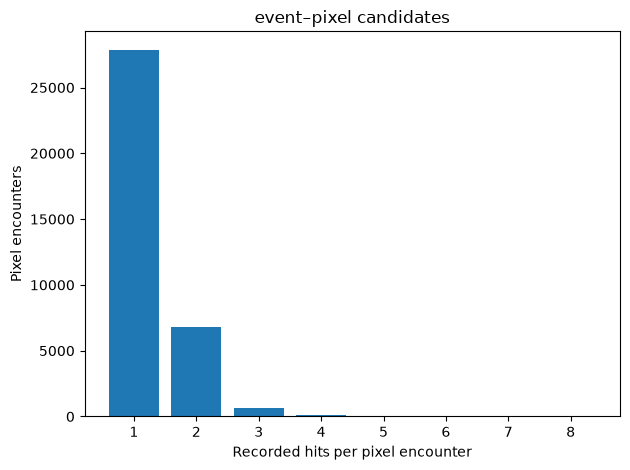

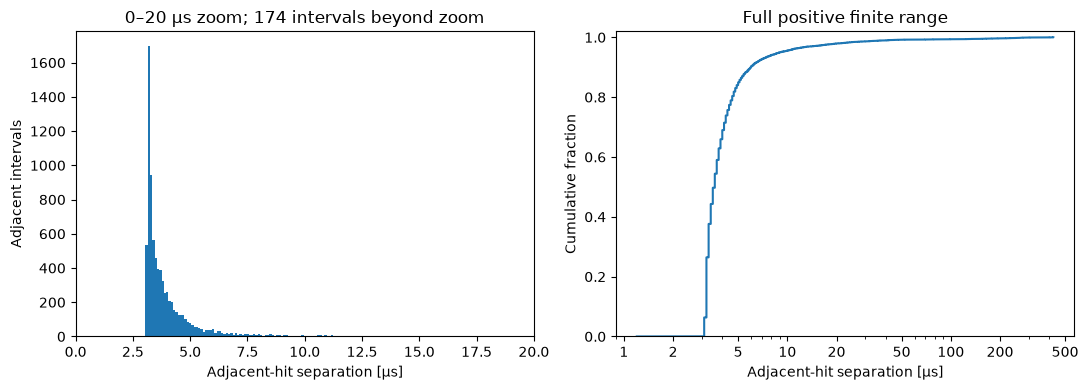

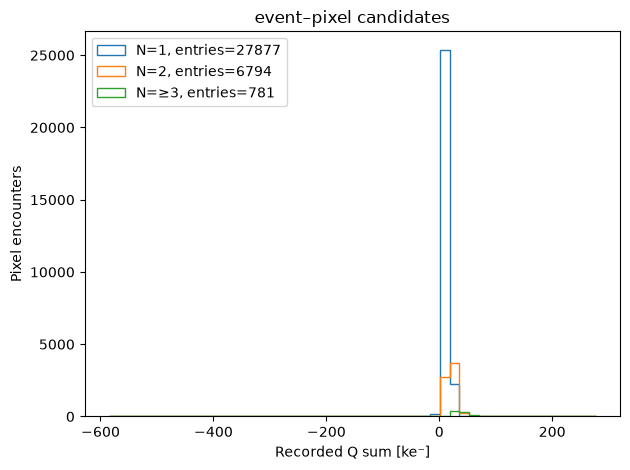

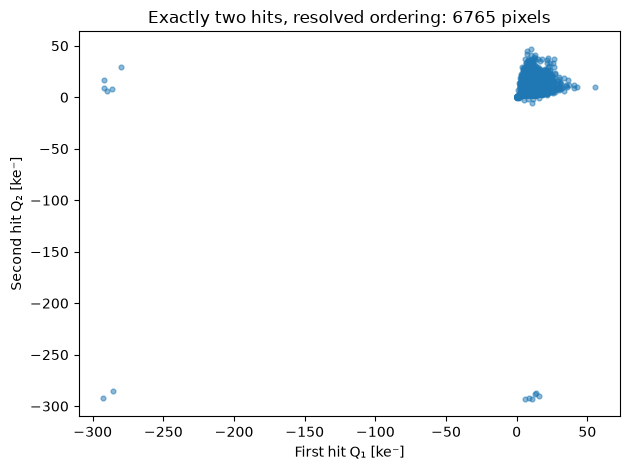

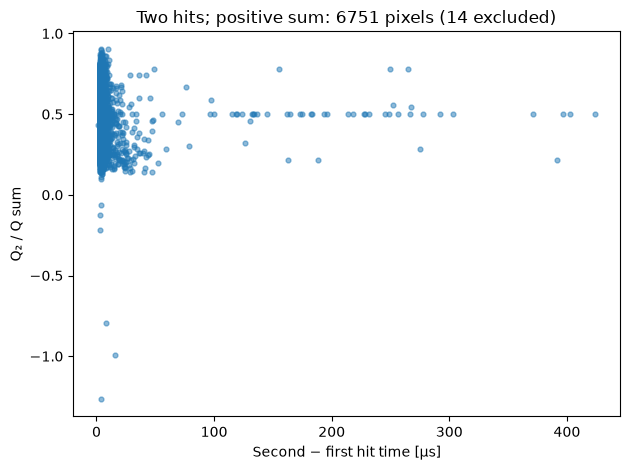

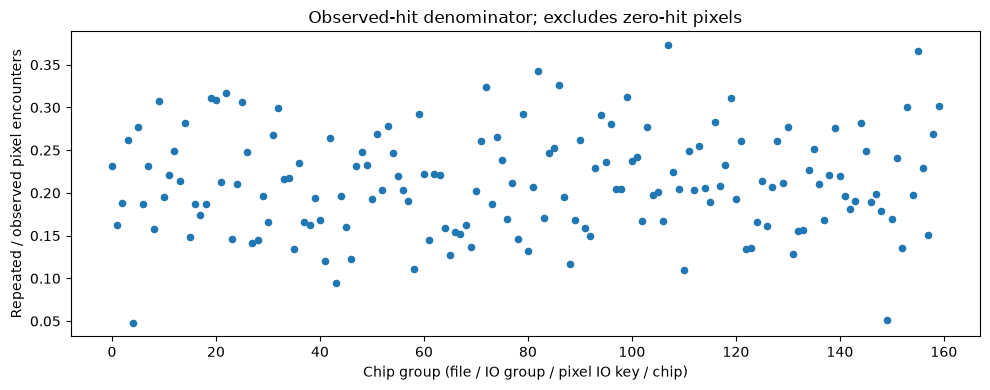

,file_id,io_group,pixel_io_channel,chip_id,channel_id,n_encounters,n_repeated,repeat_fraction
120,0,1,1,133,0,275,56,0.203636
8730,0,1,4,28,33,15,2,0.133333
8729,0,1,4,28,32,13,5,0.384615
8732,0,1,4,28,35,12,1,0.083333
8736,0,1,4,28,39,12,3,0.250000
8735,0,1,4,28,38,12,3,0.250000
8117,0,1,4,18,22,11,4,0.363636
6283,0,1,3,69,40,11,3,0.272727
3027,0,1,2,103,61,11,1,0.090909
8716,0,1,4,28,18,11,1,0.090909


In [6]:
ticks = {float(item["attrs"]["run_info"]["crs_ticks"]) for item in manifest["files"]}
if len(ticks) != 1:
    raise ValueError("Use separate scans for files with different charge clocks")
tick_us = next(iter(ticks))
figs, channel_fractions, chip_fractions = make_plots(
    tables, OUTPUT / "figures", sample="event", tick_us=tick_us)
for fig in figs.values():
    display(fig)
plt.close("all")
display(channel_fractions.sort_values("n_encounters", ascending=False).head(20))

## 7. Inspect an event and its packet records
Investigate whether repeated pixels lie on a coherent track and which hits were recovered. Prefer event 7 in the first file when present. In yz, repeated hits overlap; xz exposes reconstructed drift displacement but does not establish an absolute drift origin. Color is charge drift timing, not muon flight time or direction.

Inspect packet flags and timestamps alongside Q. A constant raw-timestamp minus drift-time offset is useful within this example, but is not imposed globally across rollover/corrected-clock cases.

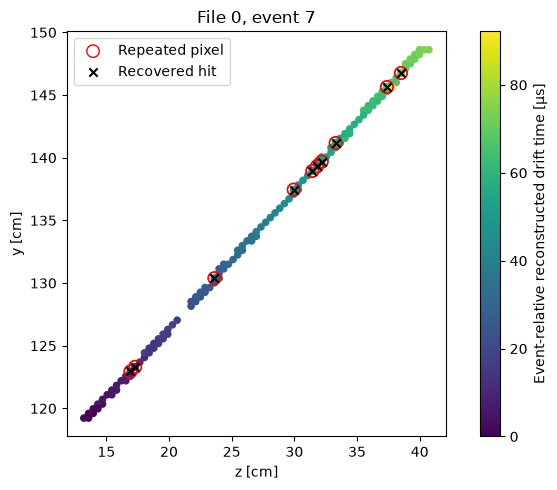

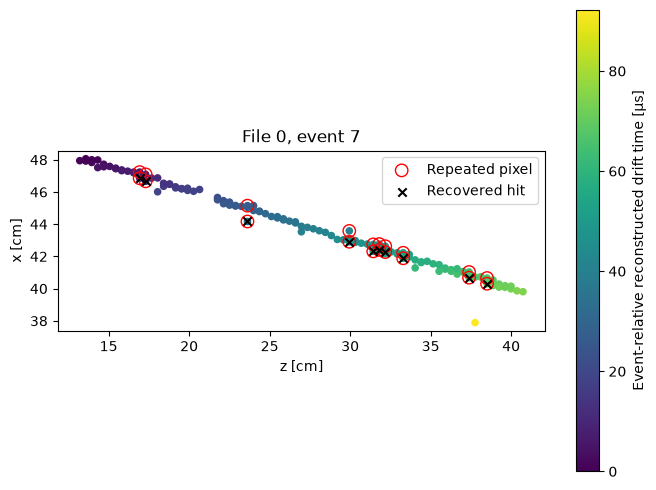

,hit_row,id,chip_id,channel_id,t_drift_us,Q,packet_row,packet_timestamp,packet_dataword,packet_valid_parity,track_id,association_role
176,219,219,97,10,26.3,9.768228,231,9256533,288,1,0,seed
177,216,216,97,12,24.4,12.696858,228,9256514,295,1,0,seed
178,218,218,97,14,26.1,7.247271,230,9256531,303,1,0,seed
179,215,215,97,17,23.6,14.927018,227,9256506,302,1,0,seed
180,217,217,97,18,25.3,7.831873,229,9256523,296,1,0,seed
181,213,213,97,21,21.8,16.679951,225,9256488,299,1,0,seed
182,214,214,97,23,23.1,4.336725,226,9256501,290,1,0,seed
183,223,223,97,52,26.6,11.037041,235,9256536,299,1,0,seed
184,220,220,97,60,26.4,7.869230,232,9256534,297,1,0,seed
185,236,236,97,60,35.3,3.844160,248,9256623,293,1,0,recovered


In [7]:
if len(hits):
    chosen = hits.loc[(hits["file_id"] == 0) & (hits["event_row"] == 7)]
    if chosen.empty:
        first = hits.iloc[0]
        chosen = hits.loc[(hits["file_id"] == first.file_id) & (hits["event_row"] == first.event_row)]
    for projection in ["yz", "xz"]:
        display(plot_event(chosen, title=f"File {chosen.file_id.iloc[0]}, event {chosen.event_row.iloc[0]}",
                           projection=projection))
    plt.close("all")
    display(chosen[["hit_row", "id", "chip_id", "channel_id", "t_drift_us", "Q",
                    "packet_row", "packet_timestamp", "packet_dataword", "packet_valid_parity",
                    "track_id", "association_role"]].head(50))

## 8. Inspect track acceptance and association losses
Investigate which cuts reject candidates and whether recovery removes part of a pixel's observed charge. Tracks use one quality-passing representative per pixel, DBSCAN, an axis-distance trim, and a refit in physical coordinates. Fit length is the extent along the fitted axis; direction sign is conventional.

Track IDs are unique only within file/event. Ambiguous multi-track associations have ID −2, unassociated hits −1. Recovery only considers retained seed pixels; it cannot discover all missing footprint pixels or recover hits outside the event. Crossing tracks can merge in clustering and require event-display checks.

`association_complete` means all original event hits for this pixel were associated to this track. It does not guarantee all deposited charge was recorded. The default track plots use this stricter subset; inspect excluded pixels to assess the resulting bias.

reason
min_pixels               993
accepted                 386
min_length                30
min_pixels_after_trim     18
relative_spread           18
Name: candidate clusters, dtype: int64

association_role
seed            29051
unassociated     8437
recovered        6474
Name: hits, dtype: int64

association_complete
True     28716
False      341
Name: track pixels, dtype: int64

,file_id,event_row,io_group,pixel_io_channel,chip_id,channel_id,track_id,multiplicity,Q_total,Q1,...,any_disabled,any_time_tie,geometry_ok,sum_quality_ok,order_quality_ok,t0_type,n_nonpositive_charge,event_pixel_nhits,association_complete,n_recovered
281,0,9,1,1,134,60,0,2,12.385142,6.695705,...,False,False,True,True,True,0,0,3,False,1
282,0,9,1,1,134,61,0,2,13.238778,5.613121,...,False,False,True,True,True,0,0,3,False,1
374,0,10,1,4,23,20,0,1,11.689204,11.689204,...,False,False,True,True,True,0,0,2,False,0
379,0,10,1,4,23,30,0,3,46.952972,11.961343,...,False,False,True,True,True,0,0,4,False,2
434,0,10,1,4,39,21,0,2,24.094666,10.034798,...,False,False,True,True,True,0,0,3,False,1
440,0,10,1,4,39,41,0,1,10.751476,10.751476,...,False,False,True,True,True,0,0,2,False,0
519,0,13,1,1,164,39,0,1,17.950683,17.950683,...,False,False,True,True,True,0,0,2,False,0
533,0,13,1,1,165,36,0,1,6.679164,6.679164,...,False,False,True,True,True,0,0,2,False,0
556,0,13,1,1,168,20,0,2,14.271711,2.607651,...,False,False,True,True,True,0,0,3,False,1
752,0,18,1,2,106,16,0,1,7.769123,7.769123,...,False,False,True,True,True,0,0,2,False,0


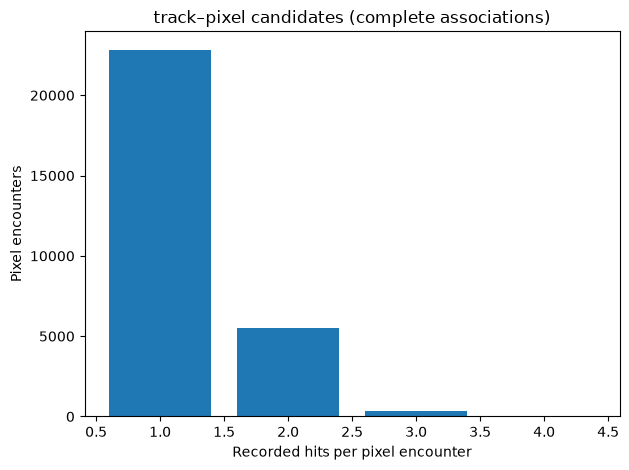

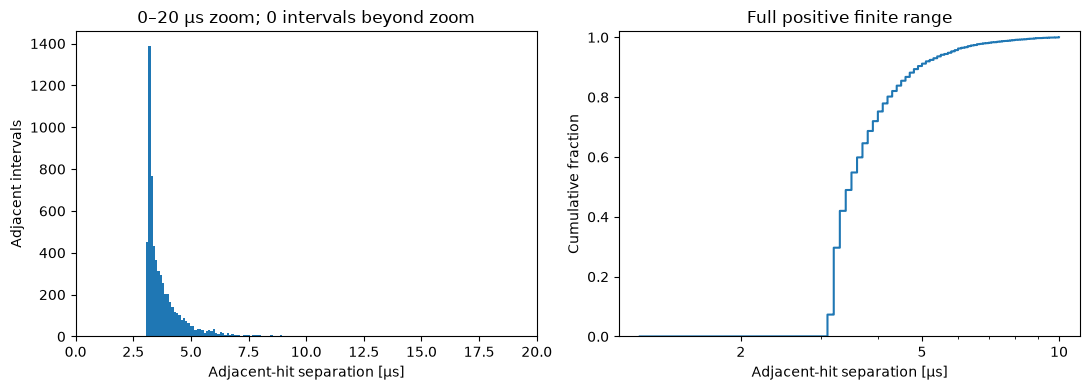

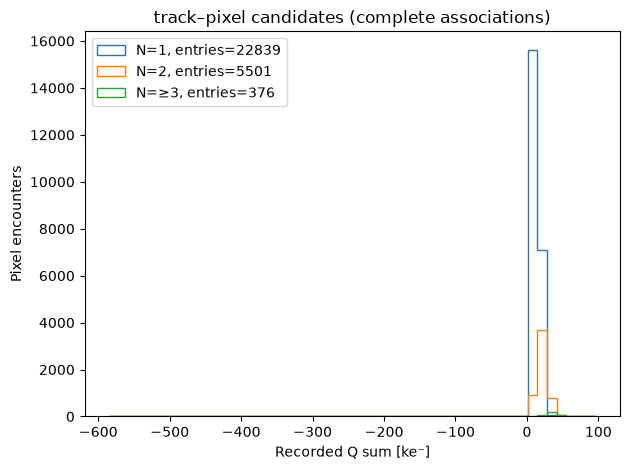

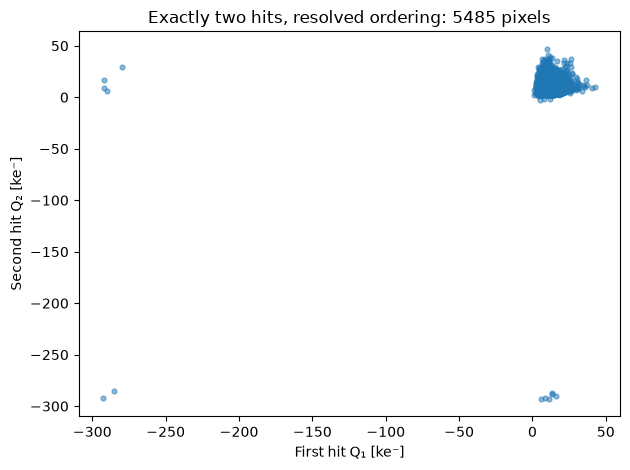

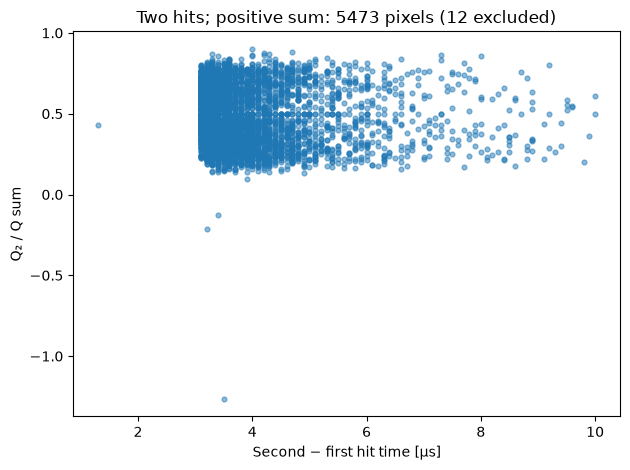

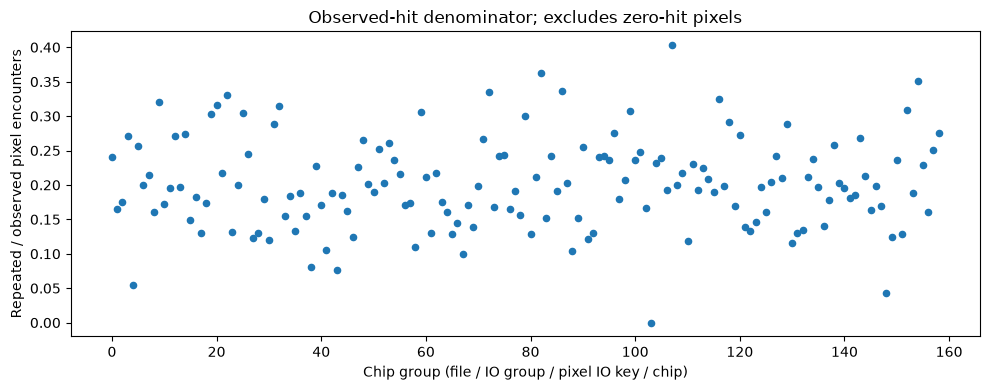

In [8]:
tracks = tables["tracks"]
display(tracks["reason"].value_counts(dropna=False).rename("candidate clusters"))
if len(hits):
    display(hits["association_role"].value_counts().rename("hits"))
track_pixels = tables["track_pixels"]
if len(track_pixels):
    display(track_pixels["association_complete"].value_counts().rename("track pixels"))
    display(track_pixels.loc[~track_pixels["association_complete"]].head(20))
figs, _, _ = make_plots(tables, OUTPUT / "figures", sample="track", tick_us=tick_us)
for fig in figs.values():
    display(fig)
plt.close("all")

## 9. Explore selection sensitivity without rereading FLOW
Investigate how minimum length and the recovery window change acceptance and multiplicity. This reuses all retained original event hits, not just fitted hits. It does not optimize cuts to reproduce a desired splitting rate. Also vary recovery distance, DBSCAN radius, minimum distinct pixels, and grouping mode in separate studies.

The comparison below includes 55 cm to expose the effect of the original selector's length cut. It is a pilot sensitivity check, not an uncertainty estimate. Compare matched angle/path-length populations before a physics interpretation.

In [9]:
from dataclasses import replace
rows = []
for min_length, recovery in [(10.0, 5.0), (10.0, 10.0), (10.0, 20.0), (55.0, 10.0)]:
    config = replace(TRACK_CONFIG, min_length_cm=min_length, recovery_us=recovery)
    accepted = recovered = complete = repeated = 0
    for _, event_hits in hits.groupby(["file_id", "event_row"]):
        associated, candidates = associate_tracks(event_hits, config)
        accepted += int(candidates["accepted"].sum())
        recovered += int((associated["association_role"] == "recovered").sum())
        _, p, _ = summarize_pixels(associated.loc[associated.track_id >= 0], track=True)
        if len(p):
            selected = p.loc[p["sum_quality_ok"] & p["association_complete"]]
            complete += len(selected)
            repeated += int((selected["multiplicity"] >= 2).sum())
    rows.append(dict(min_length_cm=min_length, recovery_us=recovery,
                     accepted_tracks=accepted, recovered_hits=recovered,
                     complete_quality_pixels=complete, repeated_pixels=repeated))
sensitivity = pd.DataFrame(rows)
display(sensitivity)
sensitivity.to_csv(OUTPUT / "sensitivity.csv", index=False)

,min_length_cm,recovery_us,accepted_tracks,recovered_hits,complete_quality_pixels,repeated_pixels
0,10.0,5.0,386,5475,27854,5015
1,10.0,10.0,386,6474,28716,5877
2,10.0,20.0,386,6669,28882,6043
3,55.0,10.0,3,127,486,105


## Interpretation checklist and next studies

- Compare exact-address versus network-mode grouping, using geometry LUT validation before adopting aliases.
- Investigate the full separation distribution and readout configuration before interpreting any peak as electronics dead time or splitting.
- Check event-boundary truncation, multiple-track pileup, packet flags, and noisy-channel concentration.
- Use track angle and path length to compare multiplicities fairly; these first plots are unnormalized recorded charge, not dQ/dx.
- Preserve t0 provenance: type NONE does not establish absolute drift distance or electron-lifetime correction.
- Repeat the bounded scan on the other files into new directories; do not combine rows without file identity.
- No truth-level charge recovery, automatic cross-event association, or validated muon classifier is implemented here.